In [1]:
from pathlib import Path
import subprocess

REPO_URL = "https://github.com/seoultechpse/fenicsx-colab.git"
ROOT = Path("/content")
REPO_DIR = ROOT / "fenicsx-colab"

subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

USE_COMPLEX = False  # <--- Set True ONLY if you need complex PETSc
USE_CLEAN = False    # <--- Set True to remove existing environment

opts_str = " ".join(
  [o for c, o in [(USE_COMPLEX, "--complex"), (USE_CLEAN, "--clean")] if c]
)

get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_fenicsx.py'} {opts_str}")

🔧 FEniCSx Setup Configuration
PETSc type      : real
Clean install   : False

⚠️  Google Drive not mounted — using local cache (/content)

🔧 Installing FEniCSx environment...

🔍 Verifying PETSc type...
✅ Installed: Real PETSc (float64)

✨ Loading FEniCSx Jupyter magic... %%fenicsx registered

✅ FEniCSx setup complete!

Next steps:
  1. Run %%fenicsx --info to verify installation
  2. Use %%fenicsx in cells to run FEniCSx code
  3. Use -np N for parallel execution (e.g., %%fenicsx -np 4)

📌 Note: Real PETSc is installed
   - Recommended for most FEM problems
   - For complex problems, reinstall with --complex


---

# Meshes from External Sources with GMSH

This notebook demonstrates creating complex geometries with GMSH and importing them into FEniCSx.

**Topics:**
- GMSH Python API
- Parametric geometry creation
- Boolean operations (fragment)
- Physical groups for markers
- Import to DOLFINx
- MeshTags usage

In [2]:
%%fenicsx

# Complete example in a single cell

# ============================================================================
# SETUP AND IMPORTS
# ============================================================================
import sys
from mpi4py import MPI
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle

# Install and import gmsh
try:
    import gmsh
except ImportError:
    print("Installing gmsh...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gmsh"])
    import gmsh

import dolfinx
import dolfinx.io
import dolfinx.mesh
import dolfinx.plot

print(f"DOLFINx version: {dolfinx.__version__}")
print(f"GMSH version: {gmsh.__version__}")
print("="*70)

# ============================================================================
# 1. INITIALIZE GMSH
# ============================================================================
print("\n1. Initializing GMSH...")

gmsh.initialize()
print("  ✓ GMSH initialized")

# ============================================================================
# 2. CREATE GMSH MODEL
# ============================================================================
print("\n2. Creating GMSH model...")

model_name = "eshelby"
gmsh.model.add(model_name)
print(f"  Model name: '{model_name}'")
print("  - Eshelby problem: circular domain with elliptical inclusion")

# ============================================================================
# 3. DEFINE PARAMETRIC GEOMETRY
# ============================================================================
print("\n3. Defining parametric geometry...")

# Parameters
center = (0, 0, 0)
aspect_ratio = 0.5
R_i = 0.3  # Inner disk semi-major axis
R_e = 0.8  # Outer disk radius

print(f"  Outer disk:")
print(f"    - Radius: {R_e}")
print(f"    - Center: {center[:2]}")

print(f"  Inner ellipse:")
print(f"    - Semi-major axis: {R_i}")
print(f"    - Semi-minor axis: {R_i * aspect_ratio}")
print(f"    - Aspect ratio: {aspect_ratio}")

# Create geometry using OpenCASCADE (OCC) backend
inner_disk = gmsh.model.occ.addDisk(*center, R_i, aspect_ratio * R_i)
outer_disk = gmsh.model.occ.addDisk(*center, R_e, R_e)

print(f"\n  GMSH objects created:")
print(f"    - Inner disk tag: {inner_disk}")
print(f"    - Outer disk tag: {outer_disk}")

# ============================================================================
# 4. BOOLEAN OPERATIONS: FRAGMENT
# ============================================================================
print("\n4. Performing boolean operation (fragment)...")

# Fragment: embed inner boundary in outer disk
whole_domain, map_to_input = gmsh.model.occ.fragment(
    [(2, outer_disk)],  # Object (outer)
    [(2, inner_disk)]   # Tool (inner)
)

print(f"  Fragment output:")
print(f"    - Resulting surfaces: {whole_domain}")
print(f"    - Map from outer disk: {map_to_input[0]}")
print(f"    - Map from inner disk: {map_to_input[1]}")
print(f"  → Surface (2, 1) is shared (the inner ellipse)")

# Synchronize model (required after OCC operations)
gmsh.model.occ.synchronize()
print("  ✓ Model synchronized")

# ============================================================================
# 5. IDENTIFY SURFACES
# ============================================================================
print("\n5. Identifying surfaces for physical groups...")

# Extract surface tags
circle_inner = [idx for (dim, idx) in map_to_input[1] if dim == 2]
circle_outer = [idx for (dim, idx) in map_to_input[0] if dim == 2 and idx not in circle_inner]

print(f"  Inner surface tags: {circle_inner}")
print(f"  Outer surface tags: {circle_outer}")

# ============================================================================
# 6. CREATE PHYSICAL SURFACE GROUPS
# ============================================================================
print("\n6. Creating physical surface groups...")

# Assign markers
marker_inner = 3
marker_outer = 7

gmsh.model.addPhysicalGroup(2, circle_inner, tag=marker_inner)
gmsh.model.addPhysicalGroup(2, circle_outer, tag=marker_outer)

print(f"  Inner inclusion: marker {marker_inner}")
print(f"  Outer matrix: marker {marker_outer}")

# ============================================================================
# 7. IDENTIFY BOUNDARIES
# ============================================================================
print("\n7. Identifying boundaries...")

# Get boundaries of each surface
inner_boundary = gmsh.model.getBoundary(
    [(2, e) for e in circle_inner],
    recursive=False,
    oriented=False
)

outer_boundary = gmsh.model.getBoundary(
    [(2, e) for e in circle_outer],
    recursive=False,
    oriented=False
)

print(f"  Inner boundary curves: {inner_boundary}")
print(f"  Outer boundary curves: {outer_boundary}")
print(f"  → Outer has 2 boundaries (donut shape)")

# Separate interface from external boundary
interface = [idx for (dim, idx) in inner_boundary if dim == 1]
ext_boundary = [idx for (dim, idx) in outer_boundary if idx not in interface and dim == 1]

print(f"\n  Interface (shared): {interface}")
print(f"  External boundary: {ext_boundary}")

# ============================================================================
# 8. CREATE PHYSICAL CURVE GROUPS
# ============================================================================
print("\n8. Creating physical curve groups...")

marker_interface = 12
marker_exterior = 15

gmsh.model.addPhysicalGroup(1, interface, tag=marker_interface)
gmsh.model.addPhysicalGroup(1, ext_boundary, tag=marker_exterior)

print(f"  Interface: marker {marker_interface}")
print(f"  External boundary: marker {marker_exterior}")

# ============================================================================
# 9. GENERATE MESH
# ============================================================================
print("\n9. Generating mesh...")

# Set mesh size
mesh_size = 0.2
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", mesh_size)
print(f"  Maximum element size: {mesh_size}")

# Generate 2D mesh
gmsh.model.mesh.generate(2)
print("  ✓ 2D mesh generated")

# Optional: Create higher-order mesh (P3 for better circle approximation)
mesh_order = 3
gmsh.model.mesh.setOrder(mesh_order)
print(f"  ✓ Mesh order set to {mesh_order} (cubic elements)")

# Get mesh statistics
num_nodes = len(gmsh.model.mesh.getNodes()[0])
num_elements = len(gmsh.model.mesh.getElements()[1][0])
print(f"\n  Mesh statistics:")
print(f"    - Nodes: {num_nodes}")
print(f"    - Elements: {num_elements}")

# ============================================================================
# 10. IMPORT TO DOLFINX
# ============================================================================
print("\n10. Importing mesh to DOLFINx...")

mesh_data = dolfinx.io.gmsh.model_to_mesh(
    gmsh.model,
    MPI.COMM_WORLD,
    0,      # Rank holding mesh
    gdim=2  # Geometric dimension
)

circular_mesh = mesh_data.mesh
cell_marker = mesh_data.cell_tags
facet_marker = mesh_data.facet_tags

print("  ✓ Mesh imported to DOLFINx")
print(f"    - Mesh dimension: {circular_mesh.topology.dim}")
print(f"    - Geometry dimension: {circular_mesh.geometry.dim}")
print(f"    - Number of cells: {circular_mesh.topology.index_map(2).size_local}")

# Finalize GMSH
gmsh.finalize()
print("  ✓ GMSH finalized")

# ============================================================================
# 11. INSPECT MESHTAGS
# ============================================================================
print("\n11. Inspecting MeshTags...")

print(f"\n  Cell markers (dimension {cell_marker.dim}):")
print(f"    - Number of tagged cells: {len(cell_marker.indices)}")
print(f"    - Unique markers: {np.unique(cell_marker.values)}")

# Count cells by marker
inner_cells = cell_marker.find(marker_inner)
outer_cells = cell_marker.find(marker_outer)
print(f"    - Inner cells (marker {marker_inner}): {len(inner_cells)}")
print(f"    - Outer cells (marker {marker_outer}): {len(outer_cells)}")

print(f"\n  Facet markers (dimension {facet_marker.dim}):")
print(f"    - Number of tagged facets: {len(facet_marker.indices)}")
print(f"    - Unique markers: {np.unique(facet_marker.values)}")

# Count facets by marker
interface_facets = facet_marker.find(marker_interface)
exterior_facets = facet_marker.find(marker_exterior)
print(f"    - Interface facets (marker {marker_interface}): {len(interface_facets)}")
print(f"    - Exterior facets (marker {marker_exterior}): {len(exterior_facets)}")

# ============================================================================
# 12. VISUALIZE GEOMETRY
# ============================================================================
print("\n12. Creating geometry visualization...")

fig, ax = plt.subplots(figsize=(8, 8))

# Plot outer circle
outer_circle = Circle((0, 0), R_e,
                      facecolor='lightblue',
                      edgecolor='blue',
                      linewidth=3,
                      alpha=0.3,
                      label=f'Outer disk (marker {marker_outer})')
ax.add_patch(outer_circle)

# Plot inner ellipse
inner_ellipse = Ellipse((0, 0), 2*R_i, 2*R_i*aspect_ratio,
                        facecolor='lightcoral',
                        edgecolor='red',
                        linewidth=3,
                        alpha=0.5,
                        label=f'Inner inclusion (marker {marker_inner})')
ax.add_patch(inner_ellipse)

# Add center point
ax.plot(0, 0, 'ko', markersize=10, label='Center')

# Add annotations
ax.annotate('', xy=(R_e, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='<->', lw=2, color='blue'))
ax.text(R_e/2, -0.05, f'$R_e={R_e}$', ha='center', fontsize=12, color='blue')

ax.annotate('', xy=(R_i, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='<->', lw=2, color='red'))
ax.text(R_i/2, 0.05, f'$R_i={R_i}$', ha='center', fontsize=12, color='red')

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Eshelby Problem Geometry', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('eshelby_geometry.png', dpi=150, bbox_inches='tight')
print("  ✓ Saved: eshelby_geometry.png")
plt.close()

# ============================================================================
# 13. VISUALIZE MESH
# ============================================================================
print("\n13. Creating mesh visualization...")

# Extract mesh data for plotting
# For 2D mesh, we'll plot the linear mesh structure
tdim = circular_mesh.topology.dim
num_cells = circular_mesh.topology.index_map(tdim).size_local

# Get cell coordinates
cells_geom = circular_mesh.geometry.x
connectivity = circular_mesh.geometry.dofmap

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Mesh with cell markers
for cell_idx in range(num_cells):
    vertices = connectivity[cell_idx][:3]  # First 3 vertices for triangle
    coords = cells_geom[vertices]

    # Close the triangle
    poly_coords = np.vstack([coords, coords[0]])

    # Get marker for this cell
    marker_idx = np.where(cell_marker.indices == cell_idx)[0]
    if len(marker_idx) > 0:
        marker = cell_marker.values[marker_idx[0]]
        color = 'lightcoral' if marker == marker_inner else 'lightblue'
    else:
        color = 'white'

    ax1.fill(poly_coords[:, 0], poly_coords[:, 1],
             facecolor=color, edgecolor='black', linewidth=0.5, alpha=0.6)

ax1.set_xlim([-1, 1])
ax1.set_ylim([-1, 1])
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title(f'Mesh with Cell Markers\n(Red=Inner, Blue=Outer)', fontweight='bold')

# Plot 2: Zoom on interface
zoom_xlim = [-0.5, 0.5]
zoom_ylim = [-0.3, 0.3]

for cell_idx in range(num_cells):
    vertices = connectivity[cell_idx][:3]
    coords = cells_geom[vertices]

    # Check if cell is in zoom region
    if (np.any((coords[:, 0] >= zoom_xlim[0]) & (coords[:, 0] <= zoom_xlim[1])) and
        np.any((coords[:, 1] >= zoom_ylim[0]) & (coords[:, 1] <= zoom_ylim[1]))):

        poly_coords = np.vstack([coords, coords[0]])

        marker_idx = np.where(cell_marker.indices == cell_idx)[0]
        if len(marker_idx) > 0:
            marker = cell_marker.values[marker_idx[0]]
            color = 'lightcoral' if marker == marker_inner else 'lightblue'
        else:
            color = 'white'

        ax2.fill(poly_coords[:, 0], poly_coords[:, 1],
                 facecolor=color, edgecolor='black', linewidth=1, alpha=0.6)

# Highlight interface region
theta = np.linspace(0, 2*np.pi, 100)
x_interface = R_i * np.cos(theta)
y_interface = R_i * aspect_ratio * np.sin(theta)
ax2.plot(x_interface, y_interface, 'g--', linewidth=2, label='Interface')

ax2.set_xlim(zoom_xlim)
ax2.set_ylim(zoom_ylim)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Zoomed View of Interface', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig('eshelby_mesh.png', dpi=150, bbox_inches='tight')
print("  ✓ Saved: eshelby_mesh.png")
plt.close()

# ============================================================================
# 14. DEMONSTRATE MESHTAGS USAGE
# ============================================================================
print("\n14. Demonstrating MeshTags usage...")

print("\n  Example: Finding cells in each region")
print(f"    cell_marker.find({marker_inner}) returns:")
print(f"      {inner_cells[:10]}... ({len(inner_cells)} total)")

print(f"\n    cell_marker.find({marker_outer}) returns:")
print(f"      {outer_cells[:10]}... ({len(outer_cells)} total)")

print("\n  Usage in variational forms:")
print("    dx = ufl.Measure('dx', subdomain_data=cell_marker, domain=mesh)")
print("    ds = ufl.Measure('ds', subdomain_data=facet_marker, domain=mesh)")
print("    ")
print("    # Different materials:")
print(f"    a = k_inner * grad(u)·grad(v) * dx({marker_inner}) +")
print(f"        k_outer * grad(u)·grad(v) * dx({marker_outer})")
print("    ")
print("    # Boundary conditions:")
print(f"    L = f * v * dx + g * v * ds({marker_exterior})")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print("\n✓ GMSH workflow completed:")
print("  1. Initialize GMSH")
print("  2. Create parametric geometry (OCC backend)")
print("  3. Boolean operations (fragment)")
print("  4. Synchronize model")
print("  5. Identify and tag surfaces")
print("  6. Identify and tag boundaries")
print("  7. Generate mesh with specified resolution")
print("  8. Set mesh order (P3 for curved boundaries)")
print("  9. Import to DOLFINx")
print(" 10. Finalize GMSH")
print("\n✓ Key concepts demonstrated:")
print("  - OCC geometry creation")
print("  - Fragment operation for embedded boundaries")
print("  - Physical groups for material/BC markers")
print("  - Higher-order meshes (P3)")
print("  - MeshTags in DOLFINx")
print("  - Integration with subdomain markers")
print("\n✓ Files generated:")
print("  - eshelby_geometry.png (geometry definition)")
print("  - eshelby_mesh.png (mesh with markers and zoom)")
print("\n✓ Mesh properties:")
print(f"  - Total cells: {circular_mesh.topology.index_map(2).size_local}")
print(f"  - Inner cells: {len(inner_cells)}")
print(f"  - Outer cells: {len(outer_cells)}")
print(f"  - Interface facets: {len(interface_facets)}")
print(f"  - Exterior facets: {len(exterior_facets)}")
print(f"  - Mesh order: P{mesh_order}")
print("\n" + "="*70)
print("Example completed successfully!")
print("="*70)

Info    : [  0%] Fragments                                                                                  
Info    : [ 10%] Fragments                                                                                  
Info    : [ 20%] Fragments                                                                                  
Info    : [ 30%] Fragments                                                                                  
Info    : [ 40%] Fragments - Performing Face-Face intersection                                                                                
Info    : [ 70%] Fragments                                                                                  
Info    : [ 80%] Fragments - Making faces                                                                                
Info    : [ 90%] Fragments - Adding holes                                                                                
                                                                    

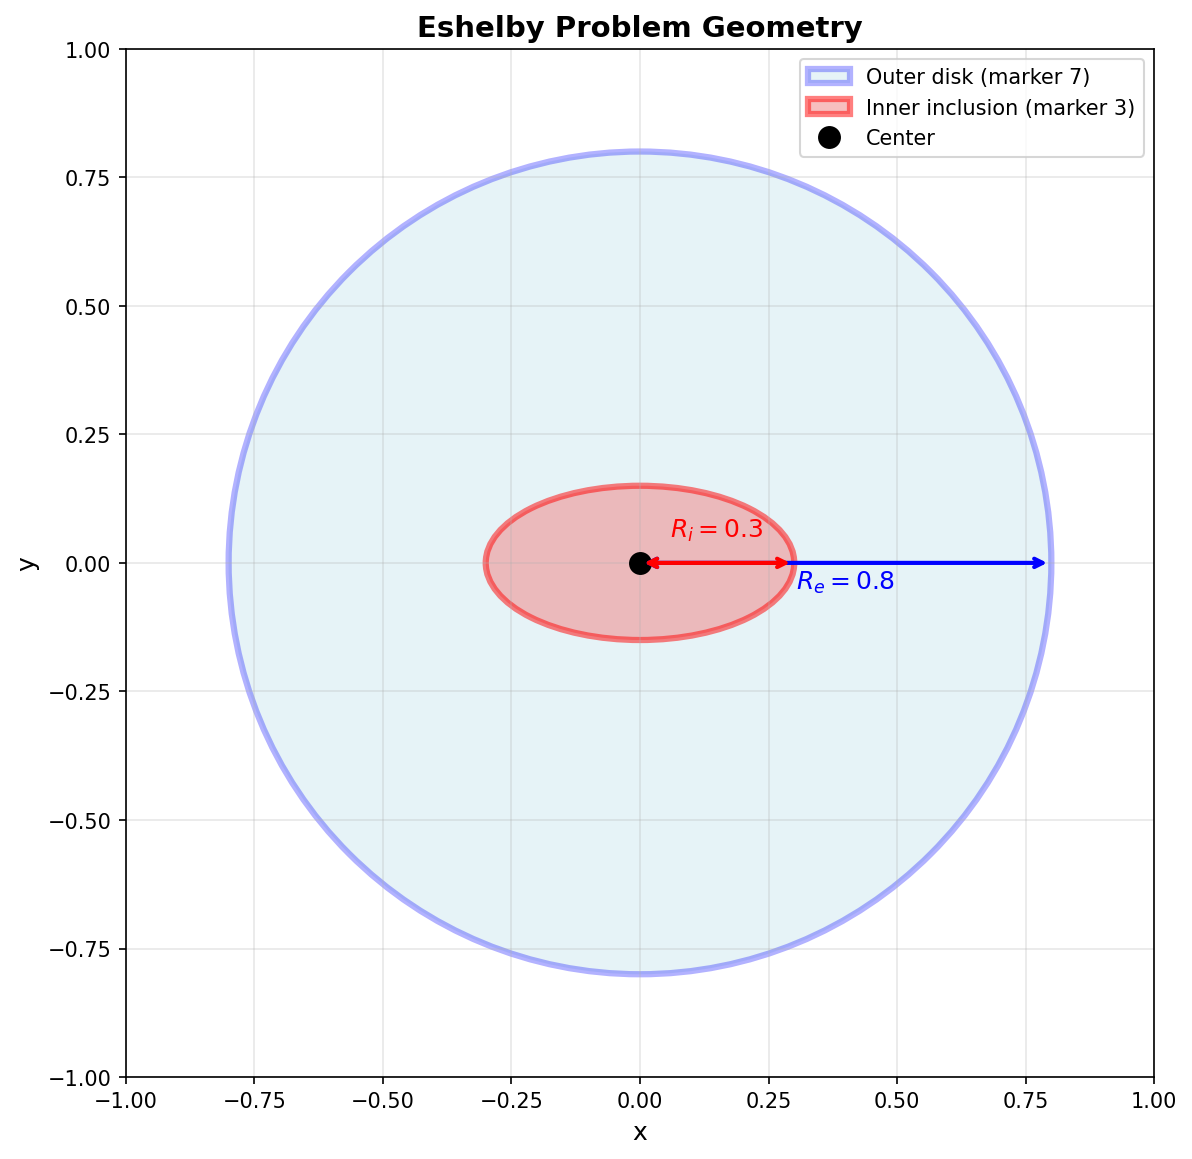

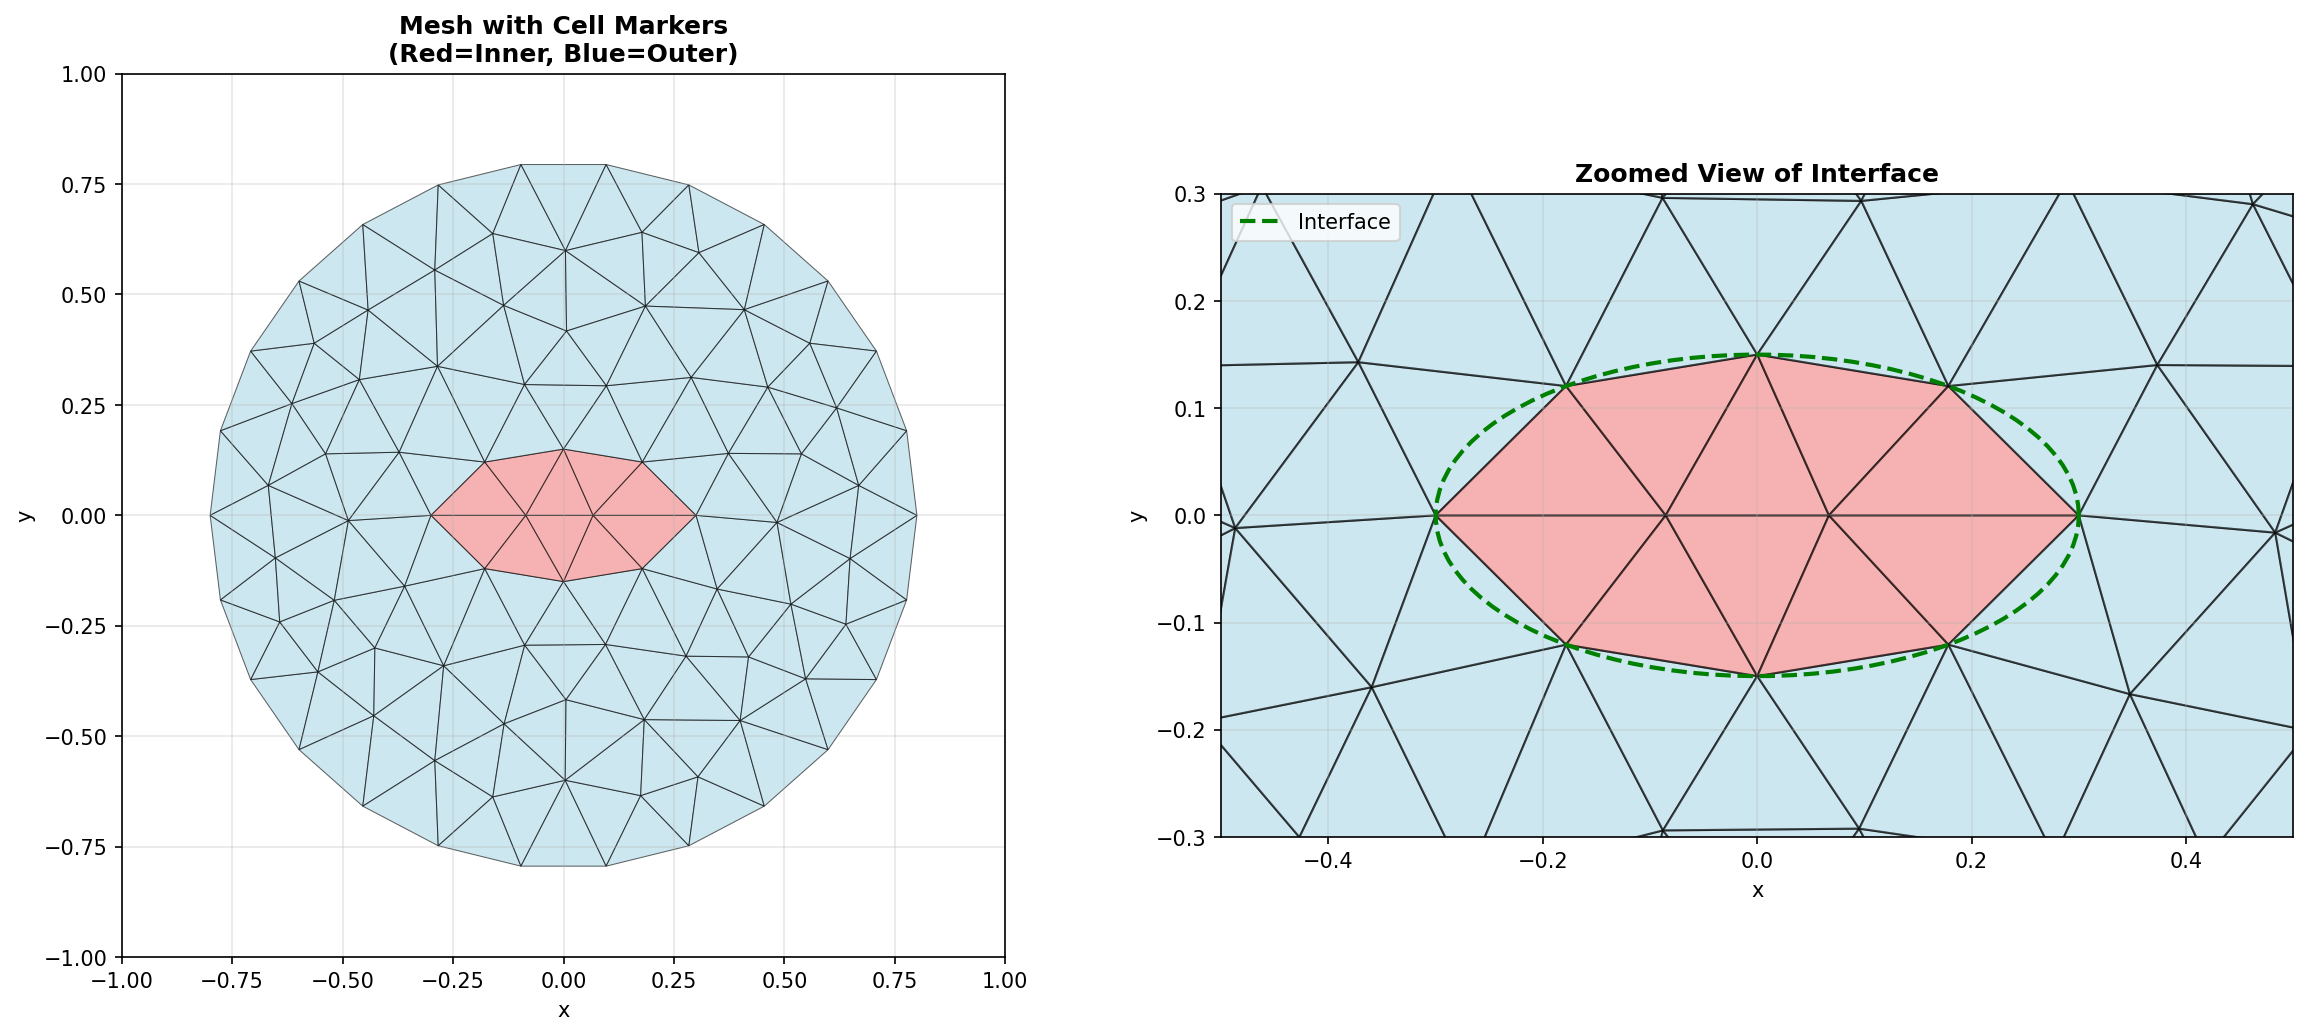

In [3]:
from IPython.display import Image, display, HTML

display(Image("eshelby_geometry.png"))
display(Image("eshelby_mesh.png"))